In [1]:
import numpy as np
import pandas as pd

from glob import glob
import cv2
import matplotlib.pylab as plt

# Reading an image

In [2]:
# reading files
dog_files = glob('../input/cat-and-dog/training_set/training_set/dogs/*.jpg')
cat_files = glob('../input/cat-and-dog/training_set/training_set/cats/*.jpg')

In [3]:
# reading images using matplotlib and cv2
img_mpl = plt.imread(cat_files[20])
img_cv2 = cv2.imread(cat_files[20])

In [4]:
# both return numpy array with a 3D shape
type(img_mpl), img_mpl.shape

(numpy.ndarray, (232, 350, 3))

## Image array
(Height, Width, Channels)
- **Height** is image height in pixels
- **Width** is image width in pixels
- **Channels** is a number of color channels (for example, 3 channels for an RGB format - red, green and blue)

Each pixel has a given value between 0 and 255 (in most cases).
There're a matrix of colors for each color channel.

We can display a distribution of pixel values as follows:

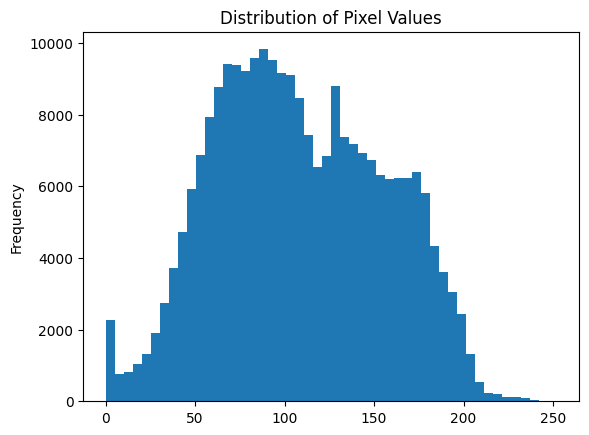

In [5]:
pd.Series(img_mpl.flatten()).plot(kind='hist',
                                 bins=50,
                                 title='Distribution of Pixel Values')
plt.show()

# Displaying an image

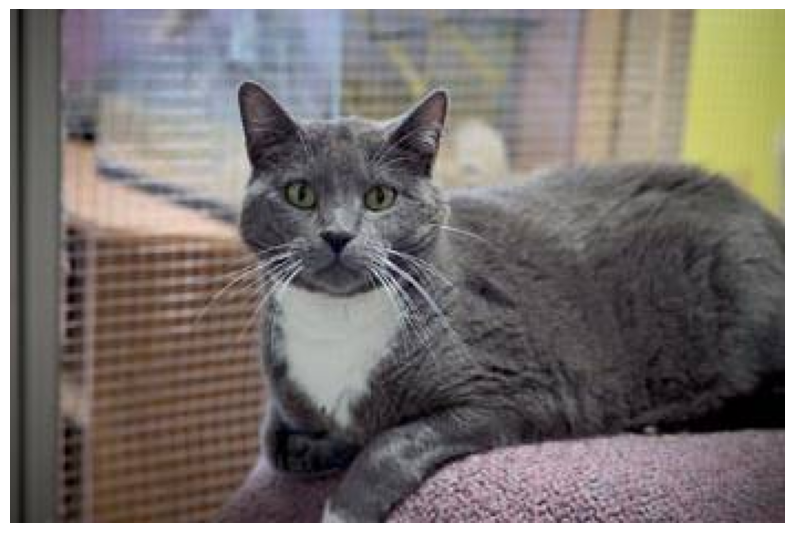

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_mpl)
ax.axis('off')
plt.show()

# Image channels

## RGB Channels
An RGB image has three channels: red, green, and blue. RGB channels roughly follow the color receptors in the human eye, and are used in computer displays and image scanners.

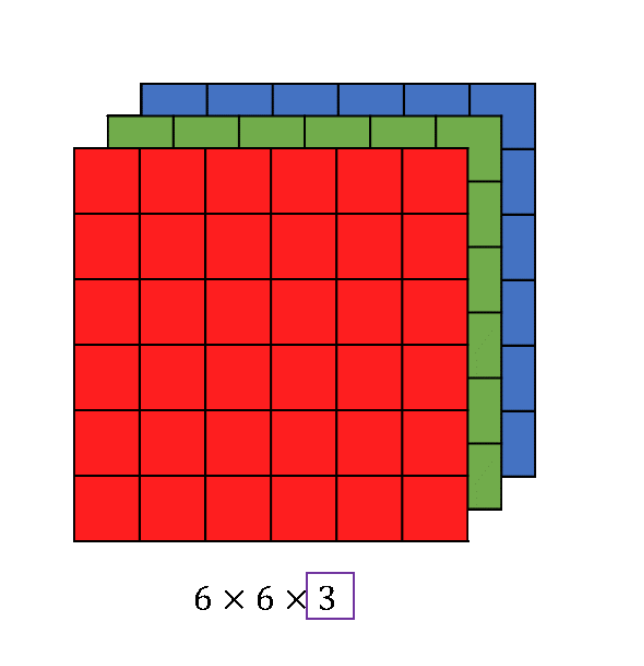
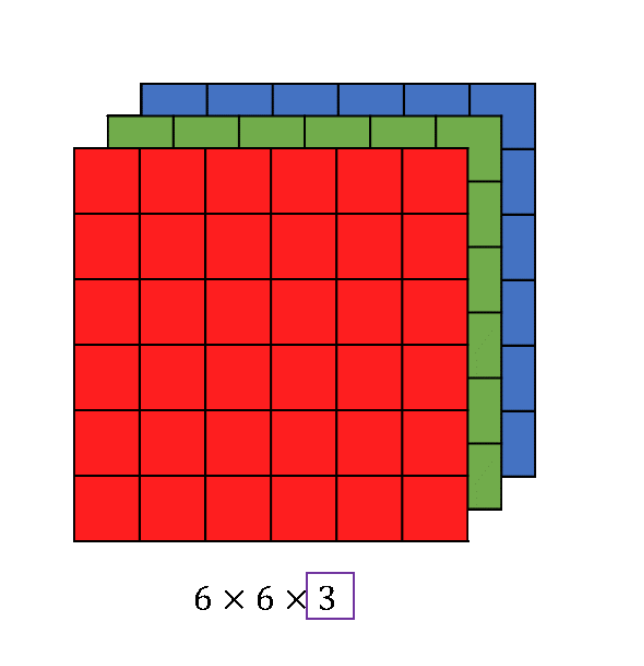

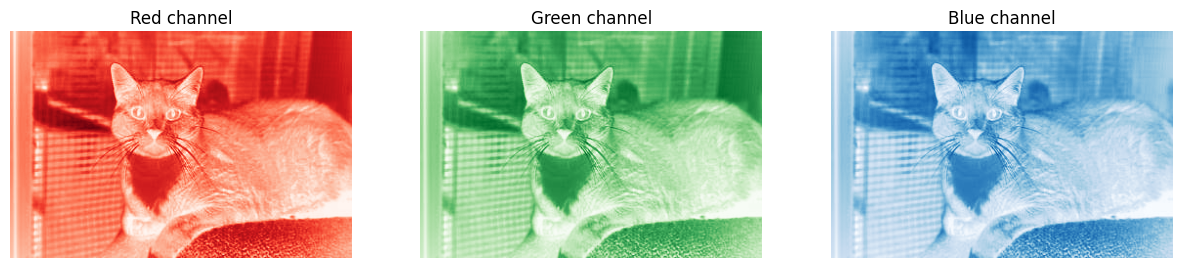

In [7]:
# displaying RGB channels of an image
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img_mpl[:, :, 0], cmap='Reds')
axs[1].imshow(img_mpl[:, :, 1], cmap='Greens')
axs[2].imshow(img_mpl[:, :, 2], cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
plt.show()

# Matplotlib vs cv2 Numpy Arrays

* **cv2** reads in channels as **BGR** (blue, green, red)
* **matplotlib** reads in channels as **RGB** (red, green, blue)

We can see the difference in perceptions here:

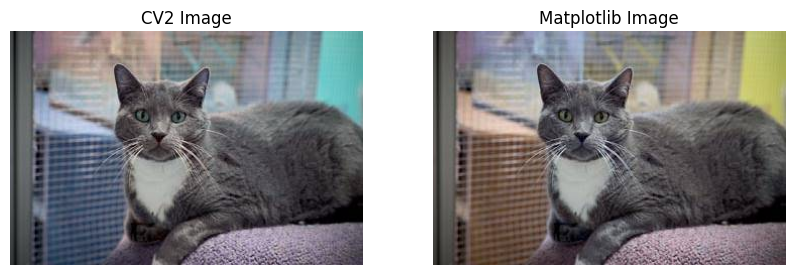

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_cv2)
axs[1].imshow(img_mpl)
axs[0].axis('off')
axs[1].axis('off')
axs[0].set_title('CV2 Image')
axs[1].set_title('Matplotlib Image')
plt.show()

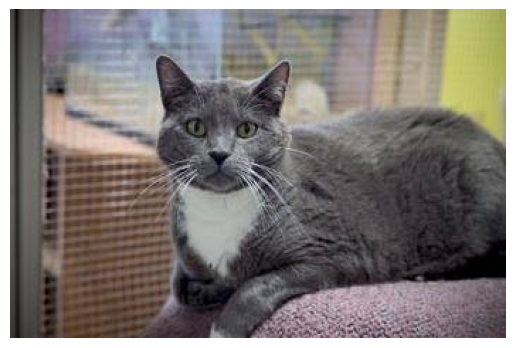

In [9]:
# converting from BGR to RGB
img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
fix, ax = plt.subplots()
ax.imshow(img_cv2_rgb)
ax.axis('off')
plt.show()

# Image Manipulation

We can resize, scale, blur an image etc.

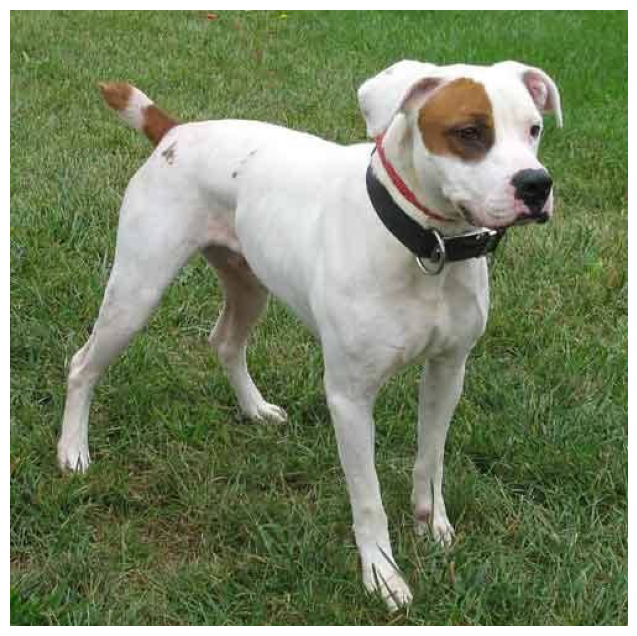

In [10]:
img = plt.imread(dog_files[4])
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.axis('off')
plt.show()

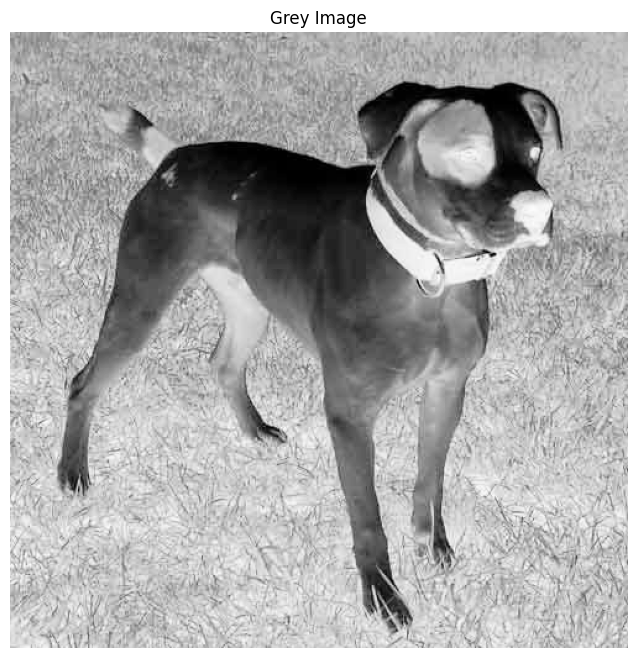

In [11]:
img_grey = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_grey, cmap='Greys')
ax.axis('off')
ax.set_title('Grey Image')
plt.show()

# Resizing and Scaling

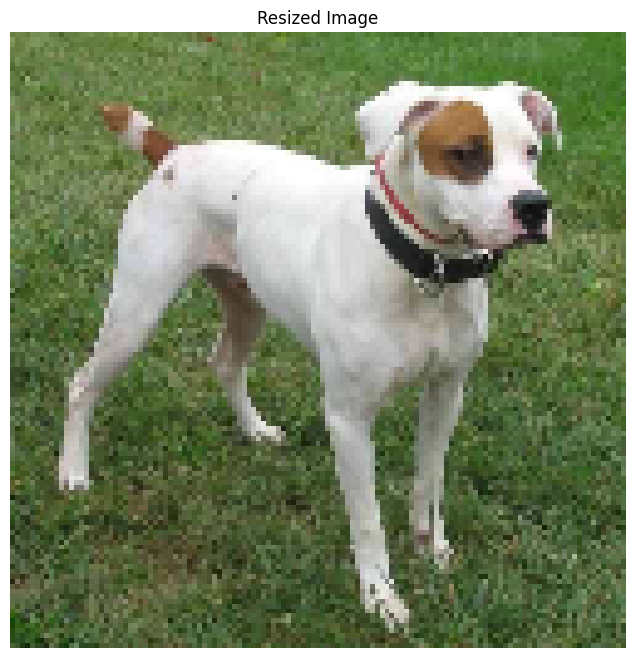

In [12]:
img_resized = cv2.resize(img, None, fx=0.25, fy=0.25)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_resized)
ax.axis('off')
ax.set_title('Resized Image')
plt.show()

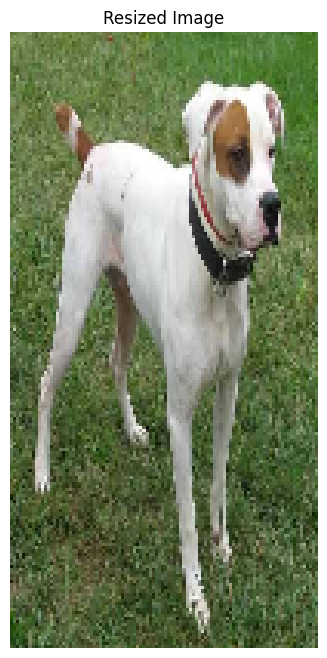

In [13]:
# different size
img_resized = cv2.resize(img, (100, 200))
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_resized)
ax.axis('off')
ax.set_title('Resized Image')
plt.show()

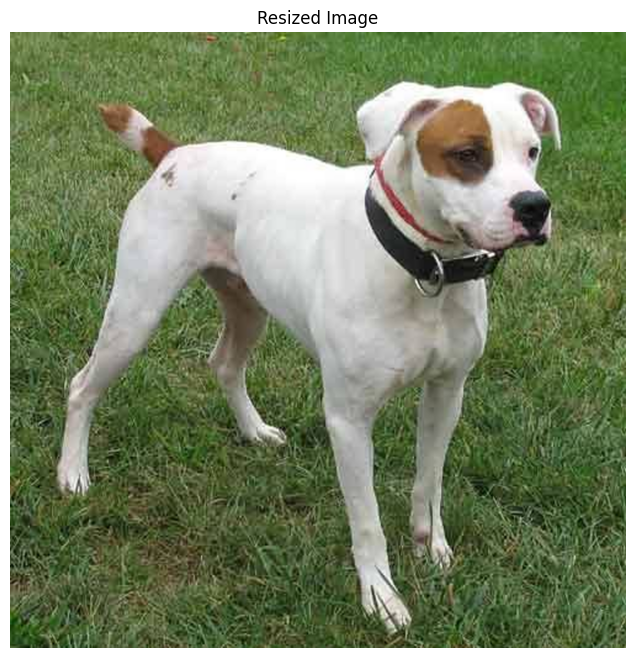

In [14]:
# scaling
img_resized = cv2.resize(img, (5000, 5000), interpolation=cv2.INTER_CUBIC)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_resized)
ax.axis('off')
ax.set_title('Resized Image')
plt.show()

# CV2 Kernels
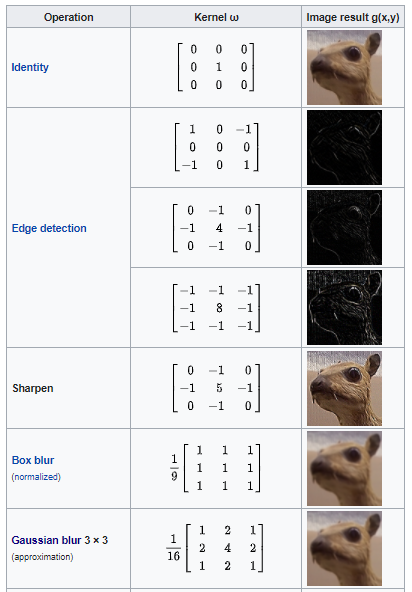
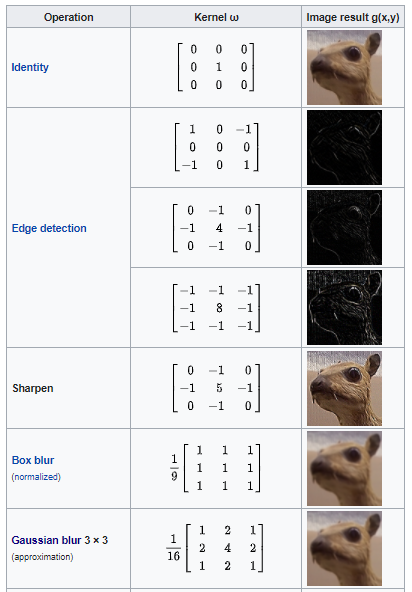

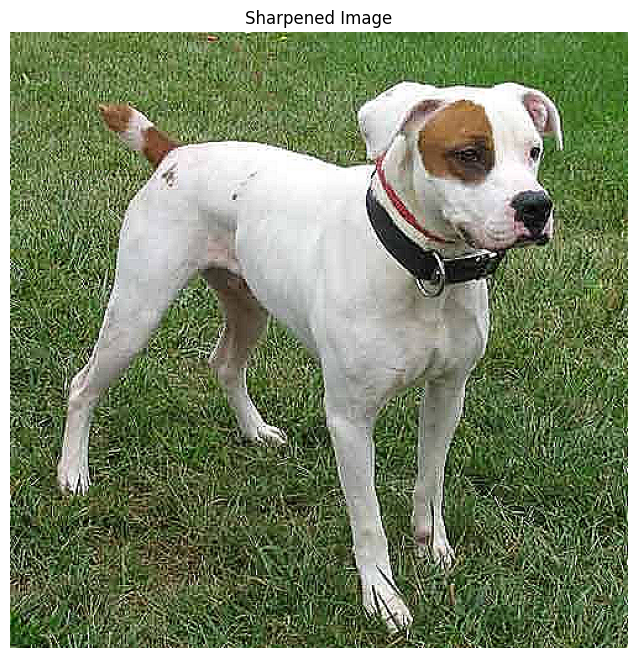

In [15]:
# sharpen image
kernel_sharpening = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]])

sharpened = cv2.filter2D(img, -1, kernel_sharpening)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(sharpened)
ax.axis('off')
ax.set_title('Sharpened Image')
plt.show()

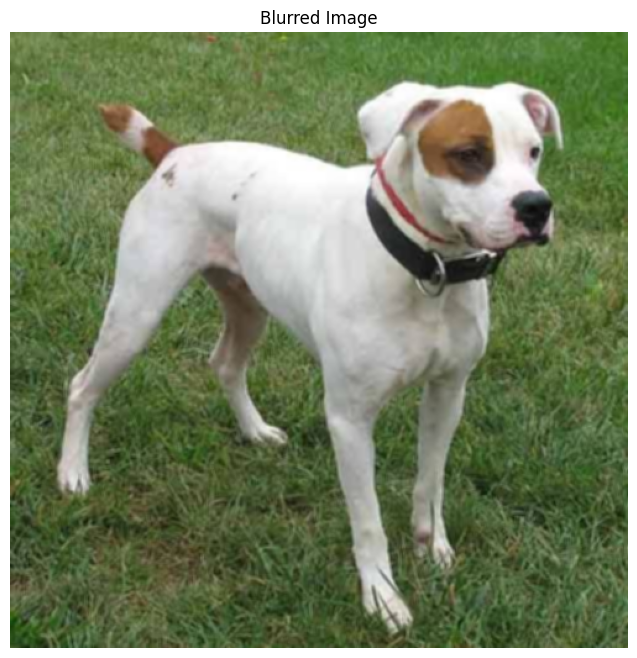

In [16]:
# blurring the image
kernel_3x3 = np.ones((3, 3), np.float32) / 9
blurred = cv2.filter2D(img, -1, kernel_3x3)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(blurred)
ax.axis('off')
ax.set_title('Blurred Image')
plt.show()

# Save Image

In [17]:
plt.imsave('mpl_dog.png', blurred)
cv2.imwrite('cv2_dog.png', blurred) # returns True

True